# Treated MonoCulture Math Modelling — 20k IC50 (Julia)

Uses DifferentialEquations.jl + Optimization.jl with an ODEProblem and a Hill-type drug effect, mirroring the style of the untreated notebook.

## 1) Packages
Load or install required Julia packages for treated IC50 modelling (logistic growth with Hill drug effect).

In [50]:
# 1) Packages (minimal)
using Pkg
pkgs = [
    "CSV", "DataFrames", "Statistics",
    "DifferentialEquations", "Optim", "Plots"
]
for p in pkgs
    try
        Base.eval(Main, :(import $(Symbol(p))))
    catch
        Pkg.add(p)
        Base.eval(Main, :(import $(Symbol(p))))
    end
end
println("✓ Packages ready: " * join(pkgs, ", "))

✓ Packages ready: CSV, DataFrames, Statistics, DifferentialEquations, Optim, Plots


## 2) Imports & Paths
Bring into scope the packages, set plotting defaults, and define filesystem paths.

In [51]:
# 2) Imports & Paths
using CSV, DataFrames, Statistics
using DifferentialEquations, Optimization, OptimizationOptimJL, BlackBoxOptim
using Optim
using Plots
default(fmt=:png, legend=:topright, lw=2, size=(900,550))

# Root and directories
ROOT = raw"c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics"
UNT_PARAMS = joinpath(ROOT, "Modelling Data Notebooks", "Untreated MonoCulture", "untreated_logistic_params_20k.csv")
TREATED_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")
OUT_DIR = joinpath(ROOT, "Modelling Data Notebooks", "Treated MonoCulture", "20k", "IC50")
mkpath(OUT_DIR)
println("Using treated averages dir: " * TREATED_DIR)
println("Output directory: " * OUT_DIR)

Using treated averages dir: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages
Output directory: c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC50


## 3) Utilities (Loaders)
Helpers to load treated day averages and untreated baseline r,K parameters.

In [52]:
# 3) Utilities (Loaders)
function load_day_averages(path::AbstractString)
    @assert isfile(path) "Missing CSV: $path"
    df = CSV.read(path, DataFrame)
    daycol = :Day ∈ names(df) ? :Day : Symbol(first(filter(n -> occursin("day", lowercase(String(n))), names(df))))
    valcol = Symbol("Mean Cells") ∈ names(df) ? Symbol("Mean Cells") : Symbol(first(filter(n -> occursin("mean", lowercase(String(n))) && occursin("cells", lowercase(String(n))), names(df))))
    x = Float64.(df[!, daycol]); y = Float64.(df[!, valcol])
    perm = sortperm(x); x = x[perm]; y = y[perm]
    return x, y
end

function load_rk_table(csv_path::AbstractString)
    df = CSV.read(csv_path, DataFrame)
    cols = Dict(lowercase(String(c)) => c for c in names(df))
    @assert all(h -> h in keys(cols), ["cell_line","r","k"]) "Untreated logistic params missing required columns"
    return Dict(Symbol(row[cols["cell_line"]]) => (Float64(row[cols["r"]]), Float64(row[cols["k"]])) for row in eachrow(df))
end

println("Loaded utility functions")

Loaded utility functions


## 4) Model (Logistic with Hill Inhibition)
Defines Hill function, ODE, solver wrapper, and objective function.

In [53]:
# 4) Model (Logistic with Hill Inhibition)
# Hill inhibition: effect(d) = d^n / (IC50^n + d^n)
hill(dose, IC50, n) = dose^n / (IC50^n + dose^n)

function treated_logistic!(du, u, p, t)
    r, K, IC50, n, dose = p
    eff = r * (1 - hill(dose, IC50, n))
    du[1] = eff * u[1] * (1 - u[1] / K)
end

function solve_model(x::Vector{Float64}, y::Vector{Float64}, r, K; IC50=1.0, n=1.0, dose=1.0)
    u0 = [max(y[1], eps())]; tspan = (x[1], x[end])
    p = [r, K, IC50, n, dose]
    prob = ODEProblem(treated_logistic!, u0, tspan, p)
    sol = solve(prob, Rosenbrock23(); saveat=x, reltol=1e-6, abstol=1e-6)
    return sol
end

function objective(θ, x, y, r, K, dose)
    IC50, n = θ
    sol = solve_model(x, y, r, K; IC50=IC50, n=n, dose=dose)
    pred = getindex.(sol.u, 1)
    return sum(abs2, y .- pred)
end

println("Model + objective ready")

Model + objective ready


## 5) Fitting Helper
Wraps optimization of IC50 and Hill coefficient n for one treated CSV.

In [54]:
# 5) Fitting Helpers (free IC50 or fixed IC50=1µM)

function _safe_loss(θ, x, y, r, K, dose)
    IC50, n = θ
    if any(!isfinite, θ) || IC50 <= 0 || n <= 0
        return 1e14
    end
    try
        sol = solve_model(x, y, r, K; IC50=IC50, n=n, dose=dose)
        pred = getindex.(sol.u, 1)
        any(!isfinite, pred) && return 1e13
        return sum(abs2, y .- pred)
    catch
        return 1e12
    end
end

function _run_single_nm(loss, lower, upper, θ0; maxiters=4000)
    opt = Optim.Options(iterations=maxiters, show_trace=false, store_trace=false, show_every=0)
    Optim.optimize(loss, lower, upper, θ0, Optim.Fminbox(Optim.NelderMead()), opt)
end

function fit_ic50_xy(x::Vector{Float64}, y::Vector{Float64}, rK::Tuple{Float64,Float64}; dose=1.0)
    r, K = rK
    lower = [1e-3, 0.1]; upper = [1e3, 5.0]
    loss(θ) = _safe_loss(θ, x, y, r, K, dose)
    res = _run_single_nm(loss, lower, upper, [1.0,1.0])
    best_res = res
    if Optim.minimum(res) > 1e11
        for _ in 1:4
            θrand = [10.0^(rand()*4 - 2), 0.1 + rand()*4.9]
            res2 = _run_single_nm(loss, lower, upper, θrand; maxiters=2000)
            Optim.minimum(res2) < Optim.minimum(best_res) && (best_res = res2)
        end
    end
    θ̂ = Optim.minimizer(best_res); IC50̂, n̂ = θ̂
    sol̂ = try solve_model(x, y, r, K; IC50=IC50̂, n=n̂, dose=dose) catch; nothing end
    (; x=copy(x), y=copy(y), r, K, IC50=IC50̂, n=n̂, ssr=_safe_loss(θ̂, x, y, r, K, dose), sol=sol̂)
end

function fit_fixed_ic50_xy(x::Vector{Float64}, y::Vector{Float64}, rK::Tuple{Float64,Float64}; dose=1.0, IC50_fixed=1.0)
    r, K = rK
    lower = [0.1]; upper = [5.0]
    loss(nvec) = _safe_loss((IC50_fixed, nvec[1]), x, y, r, K, dose)
    res = _run_single_nm(loss, lower, upper, [1.0]; maxiters=3000)
    n̂ = Optim.minimizer(res)[1]
    sol̂ = try solve_model(x, y, r, K; IC50=IC50_fixed, n=n̂, dose=dose) catch; nothing end
    (; x=copy(x), y=copy(y), r, K, IC50=IC50_fixed, n=n̂, ssr=loss([n̂]), sol=sol̂)
end

println("Fitting helpers ready")

Fitting helpers ready


## 7) Run Fits & Plot
Load untreated baseline r,K, perform treated fits for naive and cis lines, and plot results.

## 6) Quick Data Inspection & Plot
Load raw treated naive/cis CSVs, display first rows, and plot the time-course before fitting.

Inspecting treated day-average files:
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780Naive_day_averages.csv
  c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Processed_Datasets\Treated MonoCulture\20k\IC50\Averages\A2780cis_day_averages.csv
Naive rows: 14  Cis rows: 14
Naive rows: 14  Cis rows: 14


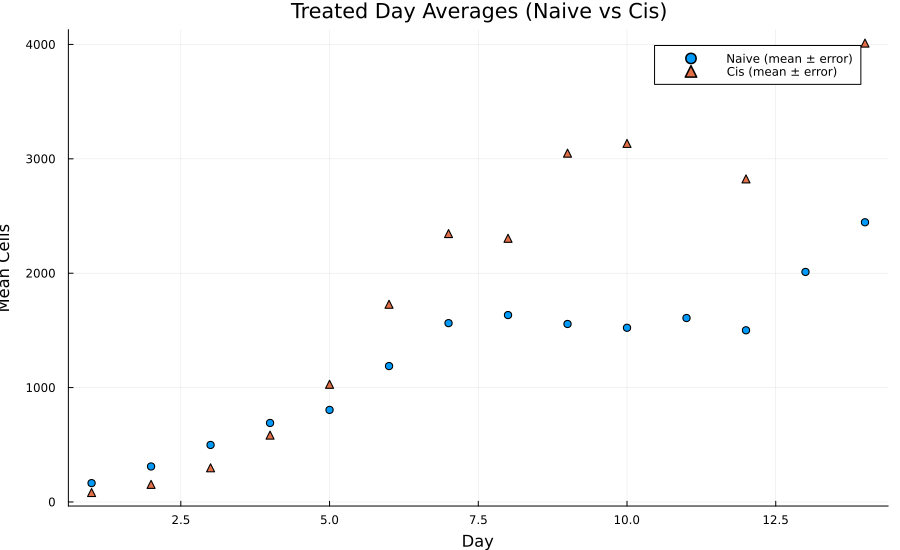

Day-average inspection complete.


In [55]:
# 6) Quick Data Inspection & Plot (Day Averages)
# Use pre-computed day-average CSVs for treated Naive and Cis lines.
AVG_DIR = joinpath(ROOT, "Processed_Datasets", "Treated MonoCulture", "20k", "IC50", "Averages")
naive_avg = joinpath(AVG_DIR, "A2780Naive_day_averages.csv")
cis_avg   = joinpath(AVG_DIR, "A2780cis_day_averages.csv")
println("Inspecting treated day-average files:\n  " * naive_avg * "\n  " * cis_avg)
@assert isfile(naive_avg) "Missing naive day averages: $(naive_avg)"
@assert isfile(cis_avg)   "Missing cis day averages: $(cis_avg)"

function load_day_avg_with_err(path::AbstractString)
    df = CSV.read(path, DataFrame)
    daycol = :Day ∈ names(df) ? :Day : first(filter(c -> occursin("day", lowercase(String(c))), names(df)))
    valcol = Symbol("Mean Cells") ∈ names(df) ? Symbol("Mean Cells") : first(filter(c -> occursin("mean", lowercase(String(c))) && occursin("cells", lowercase(String(c))), names(df)))
    errcol = Symbol("SEM Cells") ∈ names(df) ? Symbol("SEM Cells") : (Symbol("SD Cells") ∈ names(df) ? Symbol("SD Cells") : nothing)
    x = Float64.(df[!, daycol]); y = Float64.(df[!, valcol]); yerr = errcol === nothing ? nothing : Float64.(df[!, errcol])
    perm = sortperm(x); x = x[perm]; y = y[perm]; yerr = isnothing(yerr) ? nothing : yerr[perm]
    return x, y, yerr, df
end

xN, yN, yerrN, dfN = load_day_avg_with_err(naive_avg)
xC, yC, yerrC, dfC = load_day_avg_with_err(cis_avg)
println("Naive rows: ", nrow(dfN), "  Cis rows: ", nrow(dfC))

plt = scatter(xN, yN; yerror=yerrN, marker=:circle, label="Naive (mean ± error)", xlabel="Day", ylabel="Mean Cells", title="Treated Day Averages (Naive vs Cis)")
scatter!(plt, xC, yC; yerror=yerrC, marker=:utriangle, label="Cis (mean ± error)")
display(plt)
println("Day-average inspection complete.")

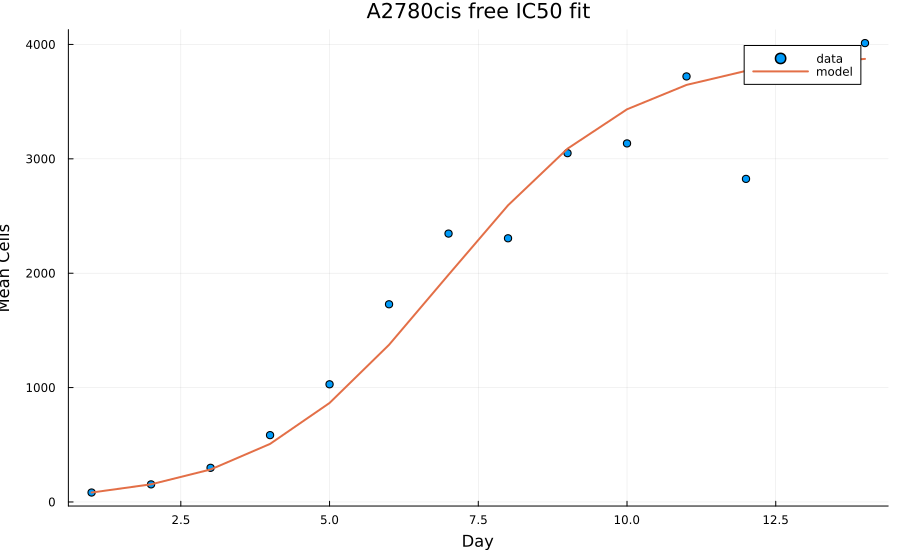

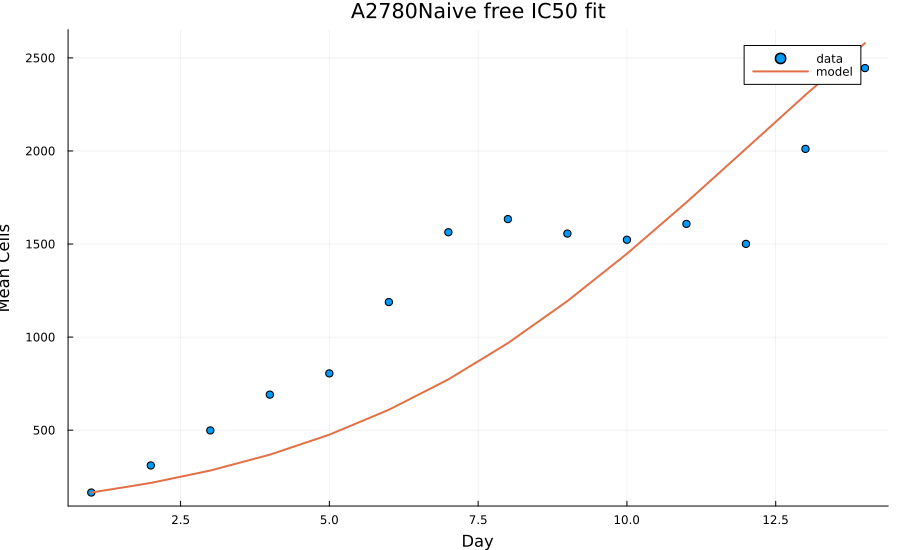

Saved free-IC50 params → c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC50\treated_ic50_20k_dayavg_fit_params_freeIC50.csv


Row,cell_line,r,K,IC50,n,SSR
,String,Float64,Float64,Float64,Float64,Float64
1,A2780cis,0.71548,3914.9,439.944,0.362622,1.38299e6
2,A2780Naive,0.770405,4068.59,0.825624,2.75812,2.18603e6


In [58]:
# 7) Run Fits & Plot (Free IC50 & n)
for sym in (:xN, :yN, :xC, :yC)
    @assert isdefined(Main, sym) "Run Section 6 first (data load)."
end
rk = load_rk_table(UNT_PARAMS)
fits = Dict{Symbol,Any}(
    :A2780Naive => fit_ic50_xy(copy(xN), copy(yN), rk[:A2780Naive]),
    :A2780cis   => fit_ic50_xy(copy(xC), copy(yC), rk[:A2780cis])
)

# Plot & export
for (k,f) in fits
    if f !== nothing && f.sol !== nothing
        plt = scatter(f.x, f.y; label="data", xlabel="Day", ylabel="Mean Cells", title="$(k) free IC50 fit")
        plot!(plt, f.sol.t, getindex.(f.sol.u,1); label="model")
        savefig(plt, joinpath(OUT_DIR, "$(String(k))_freeIC50_fit.png"))
        display(plt)
    else
        @warn "Free fit failed" k
    end
end

out_csv = joinpath(OUT_DIR, "treated_ic50_20k_dayavg_fit_params_freeIC50.csv")
rows = DataFrame(cell_line=String[], r=Float64[], K=Float64[], IC50=Float64[], n=Float64[], SSR=Float64[])
for (name,f) in fits
    if f !== nothing
        push!(rows, (; cell_line=String(name), r=f.r, K=f.K, IC50=f.IC50, n=f.n, SSR=f.ssr))
    end
end
CSV.write(out_csv, rows)
println("Saved free-IC50 params → " * out_csv)
rows

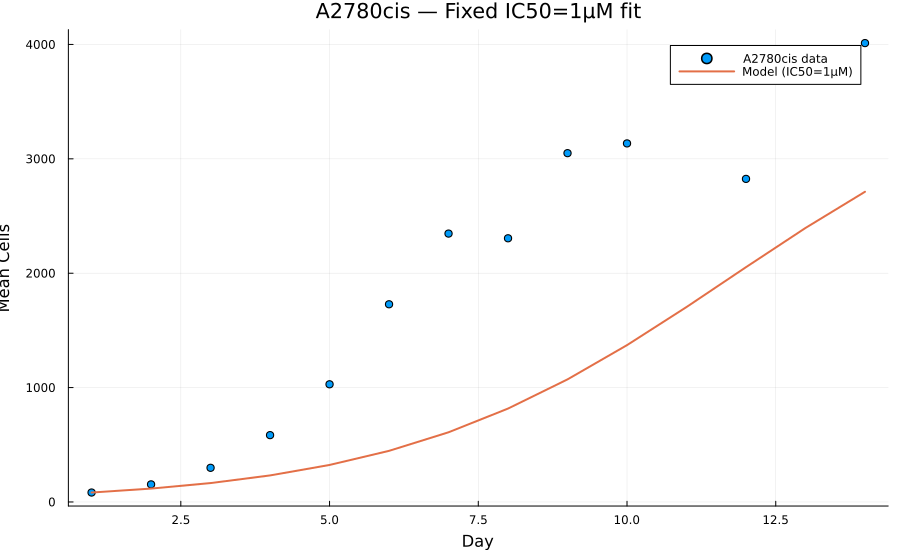

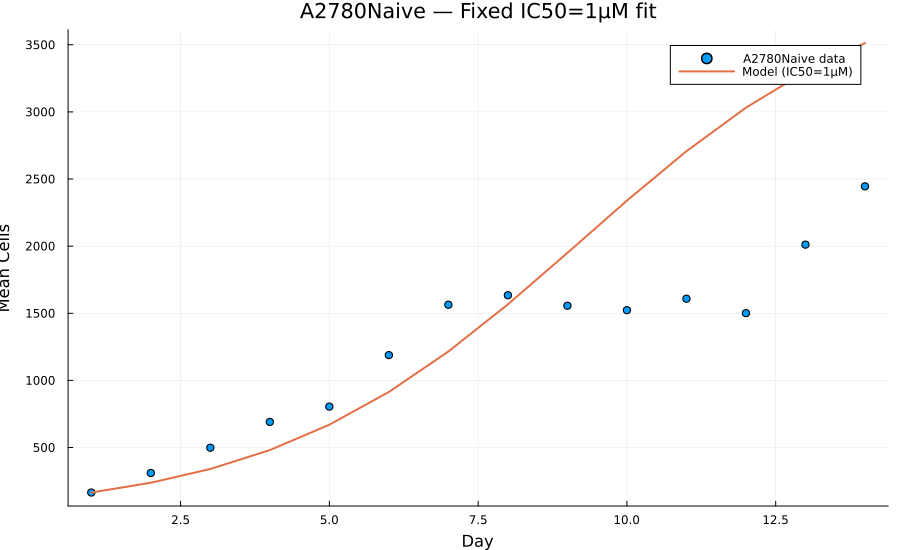

Saved fixed-IC50 fit params → c:/Users/MainFrameTower/Desktop/CancerGrowthDynamics\Modelling Data Notebooks\Treated MonoCulture\20k\IC50\treated_ic50_20k_dayavg_fit_params_fixedIC50_1uM.csv


Row,cell_line,r,K,IC50,n,SSR
,String,Float64,Float64,Float64,Float64,Float64
1,A2780cis,0.71548,3914.9,1.0,1.525,2.31724e7
2,A2780Naive,0.770405,4068.59,1.0,1.525,7.46573e6


In [57]:
# 7b) Fixed IC50 (=1 µM) Fits & Plot
for sym in (:xN, :yN, :xC, :yC)
    @assert isdefined(Main, sym) "Symbol $(sym) not defined — run Section 6 first."
end
@assert isdefined(Main, :rk) "Run the previous fits cell to load rk first"

fixed_fits = Dict{Symbol,Any}()
fixed_fits[:A2780Naive] = fit_fixed_ic50_xy(copy(xN), copy(yN), rk[:A2780Naive]; dose=1.0, IC50_fixed=1.0)
fixed_fits[:A2780cis]   = fit_fixed_ic50_xy(copy(xC), copy(yC), rk[:A2780cis]; dose=1.0, IC50_fixed=1.0)

for (k,f) in fixed_fits
    if f !== nothing && f.sol !== nothing
        plt = scatter(f.x, f.y; label=String(k)*" data", xlabel="Day", ylabel="Mean Cells", title=String(k)*" — Fixed IC50=1µM fit")
        plot!(plt, f.sol.t, getindex.(f.sol.u,1); label="Model (IC50=1µM)")
        display(plt)
        savefig(plt, joinpath(OUT_DIR, "$(String(k))_dayavg_fit_fixedIC50.png"))
    else
        @warn "Fixed-IC50 fit failed or no solution" k
    end
end

# Export table
fixed_out = joinpath(OUT_DIR, "treated_ic50_20k_dayavg_fit_params_fixedIC50_1uM.csv")
rows_fixed = DataFrame(cell_line=String[], r=Float64[], K=Float64[], IC50=Float64[], n=Float64[], SSR=Float64[])
for (name,f) in fixed_fits
    if f !== nothing
        push!(rows_fixed, (; cell_line=String(name), r=f.r, K=f.K, IC50=f.IC50, n=f.n, SSR=f.ssr))
    end
end
CSV.write(fixed_out, rows_fixed)
println("Saved fixed-IC50 fit params → " * fixed_out)
rows_fixed